# Cease and Desist Document Processing System

**Agents:**
- **Document Loader Agent** - Reads and extracts text from PDFs
- **Classification Agent** - Labels each doc as CEASE / UNCERTAIN / IRRELEVANT
- **Database Agent** - Persists valid C&D records to SQLite
- **Archive Agent** - Logs irrelevant docs to a flat file
- **HITL Agent** - Presents ambiguous docs for human review
- **Audit Agent** - Maintains a full compliance trail

## 1. Install Dependencies

In [1]:
!pip install -q \
    langchain \
    langchain-groq \
    langchain-community \
    langgraph \
    pypdf \
    pydantic \
    tabulate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.7/333.7 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 1.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


## 2. API Key Setup

Add `GROQ_API_KEY` to Colab Secrets

In [2]:
import os

try:
    from google.colab import userdata
    os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
    print("GROQ_API_KEY loaded from Colab secrets")
except Exception:
    os.environ["GROQ_API_KEY"] = "YOUR_GROQ_API_KEY_HERE"

GROQ_API_KEY loaded from Colab secrets


## 3. Imports and LLM

In [3]:
import sqlite3
import json
import re
import textwrap
from datetime import datetime
from pathlib import Path
from typing import TypedDict, Annotated, Literal, List, Optional

from pypdf import PdfReader
from pydantic import BaseModel, Field
from tabulate import tabulate

from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
    api_key=os.environ["GROQ_API_KEY"],
)

print("LLM ready:", llm.model_name)

LLM ready: llama-3.3-70b-versatile


## 4. Pydantic Schemas

In [4]:
class ClassificationResult(BaseModel):
    """Structured output from the Classification Agent."""
    label: Literal["CEASE", "UNCERTAIN", "IRRELEVANT"] = Field(
        description="Document classification label"
    )
    confidence: float = Field(
        ge=0.0, le=1.0,
        description="Confidence score between 0 and 1"
    )
    reason: str = Field(
        description="One-paragraph justification for the label"
    )
    sender_name: Optional[str] = Field(None, description="Name of the sender or law firm")
    recipient_name: Optional[str] = Field(None, description="Name of the recipient")
    violation_type: Optional[str] = Field(None, description="Type of alleged violation")
    deadline: Optional[str] = Field(None, description="Response deadline if stated")
    demands_summary: Optional[str] = Field(None, description="Brief summary of demands")


class DocumentRecord(BaseModel):
    """Record stored in the database for CEASE documents."""
    doc_id: str
    file_name: str
    date_received: str
    sender_name: Optional[str]
    recipient_name: Optional[str]
    violation_type: Optional[str]
    deadline: Optional[str]
    demands_summary: Optional[str]
    classification_reason: str
    confidence: float
    hitl_reviewed: bool = False
    human_decision: Optional[str] = None


print("Schemas defined")

Schemas defined


## 5. Graph State

In [5]:
class AgentState(TypedDict):
    # input
    file_path: str
    file_name: str
    date_received: str

    # loader output
    raw_text: str
    load_error: Optional[str]

    # classification output
    classification: Optional[ClassificationResult]

    # human-in-the-loop
    human_decision: Optional[Literal["CEASE", "IRRELEVANT", "SKIP"]]

    # downstream
    db_record: Optional[DocumentRecord]
    archive_record: Optional[dict]

    # audit trail - every agent appends here
    audit_entries: List[dict]

    # langgraph message tracing
    messages: Annotated[list, add_messages]


print("AgentState defined")

AgentState defined


## 6. Storage Layer

In [6]:
DB_PATH      = "cease_desist.db"
ARCHIVE_PATH = "irrelevant_archive.jsonl"
AUDIT_PATH   = "audit_log.jsonl"


def init_db():
    conn = sqlite3.connect(DB_PATH)
    conn.execute("""
        CREATE TABLE IF NOT EXISTS cease_records (
            doc_id                TEXT PRIMARY KEY,
            file_name             TEXT,
            date_received         TEXT,
            sender_name           TEXT,
            recipient_name        TEXT,
            violation_type        TEXT,
            deadline              TEXT,
            demands_summary       TEXT,
            classification_reason TEXT,
            confidence            REAL,
            hitl_reviewed         INTEGER DEFAULT 0,
            human_decision        TEXT,
            inserted_at           TEXT
        )
    """)
    conn.commit()
    conn.close()


def insert_cease_record(record: DocumentRecord):
    conn = sqlite3.connect(DB_PATH)
    conn.execute(
        "INSERT OR REPLACE INTO cease_records VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?)",
        (
            record.doc_id, record.file_name, record.date_received,
            record.sender_name, record.recipient_name, record.violation_type,
            record.deadline, record.demands_summary, record.classification_reason,
            record.confidence, int(record.hitl_reviewed), record.human_decision,
            datetime.utcnow().isoformat()
        )
    )
    conn.commit()
    conn.close()


def append_archive(entry: dict):
    with open(ARCHIVE_PATH, "a") as f:
        f.write(json.dumps(entry) + "\n")


def append_audit(entry: dict):
    with open(AUDIT_PATH, "a") as f:
        f.write(json.dumps(entry) + "\n")


init_db()
print("Storage layer ready")

Storage layer ready


## 7. Agent Nodes

In [7]:
# --- Node 1: Document Loader ---

def document_loader_agent(state: AgentState) -> AgentState:
    audit = state.get("audit_entries", [])

    try:
        reader = PdfReader(state["file_path"])
        pages  = [p.extract_text() or "" for p in reader.pages]
        text   = "\n".join(pages).strip()

        if not text:
            raise ValueError("No extractable text -- may be a scanned image PDF")

        audit.append({
            "timestamp": datetime.utcnow().isoformat(),
            "agent":     "DocumentLoaderAgent",
            "file":      state["file_name"],
            "status":    "success",
            "detail":    f"Extracted {len(text)} characters from {len(pages)} page(s)"
        })
        return {**state, "raw_text": text, "load_error": None, "audit_entries": audit}

    except Exception as e:
        audit.append({
            "timestamp": datetime.utcnow().isoformat(),
            "agent":     "DocumentLoaderAgent",
            "file":      state["file_name"],
            "status":    "error",
            "detail":    str(e)
        })
        return {**state, "raw_text": "", "load_error": str(e), "audit_entries": audit}


# --- Node 2: Classification Agent ---

CLASSIFICATION_SYSTEM = """
You are a legal document classification specialist. Classify the incoming document
into exactly one of these three categories:

  CEASE      - A clear, formal Cease and Desist letter with explicit legal demands,
               citations of law, a specific deadline, and a directive to stop certain
               activities. The sender identity and violation are clearly stated.

  UNCERTAIN  - A document that hints at a cease-and-desist intent but is vague or
               incomplete. It may request verification or a pause in communications
               without making an absolute demand. Human review is required.

  IRRELEVANT - A document unrelated to cease and desist requests.

Respond ONLY with a valid JSON object -- no markdown, no preamble:
{
  "label":           "CEASE" | "UNCERTAIN" | "IRRELEVANT",
  "confidence":      0.0 to 1.0,
  "reason":          "<one paragraph justification>",
  "sender_name":     "<sender or law firm name, or null>",
  "recipient_name":  "<recipient name, or null>",
  "violation_type":  "<e.g. Copyright Infringement, or null>",
  "deadline":        "<deadline date string, or null>",
  "demands_summary": "<brief summary of demands, or null>"
}
"""


def classification_agent(state: AgentState) -> AgentState:
    audit = state.get("audit_entries", [])

    if state.get("load_error"):
        result = ClassificationResult(
            label="UNCERTAIN",
            confidence=0.0,
            reason=f"Document could not be loaded: {state['load_error']}"
        )
        audit.append({
            "timestamp": datetime.utcnow().isoformat(),
            "agent":     "ClassificationAgent",
            "file":      state["file_name"],
            "status":    "skipped",
            "detail":    "Skipped due to load error"
        })
        return {**state, "classification": result, "audit_entries": audit}

    text_snippet = state["raw_text"][:4000]
    messages = [
        SystemMessage(content=CLASSIFICATION_SYSTEM),
        HumanMessage(content=f"Classify the following document:\n\n{text_snippet}")
    ]

    try:
        response = llm.invoke(messages)
        raw_json = response.content.strip()
        raw_json = re.sub(r"^```[a-z]*\n?", "", raw_json)
        raw_json = re.sub(r"\n?```$", "", raw_json)
        result   = ClassificationResult(**json.loads(raw_json))

        audit.append({
            "timestamp":  datetime.utcnow().isoformat(),
            "agent":      "ClassificationAgent",
            "file":       state["file_name"],
            "status":     "success",
            "label":      result.label,
            "confidence": result.confidence,
            "detail":     result.reason[:200]
        })
        return {
            **state,
            "classification": result,
            "audit_entries":  audit,
            "messages": [AIMessage(content=f"Classified as {result.label} ({result.confidence:.0%})")]
        }

    except Exception as e:
        result = ClassificationResult(
            label="UNCERTAIN",
            confidence=0.0,
            reason=f"Classification failed: {e}"
        )
        audit.append({
            "timestamp": datetime.utcnow().isoformat(),
            "agent":     "ClassificationAgent",
            "file":      state["file_name"],
            "status":    "error",
            "detail":    str(e)
        })
        return {**state, "classification": result, "audit_entries": audit}


# --- Router after Classification ---

def classification_router(state: AgentState) -> str:
    label = state["classification"].label
    if label == "CEASE":
        return "database_agent"
    elif label == "IRRELEVANT":
        return "archive_agent"
    else:
        return "hitl_agent"


# --- Node 3: Database Agent ---

def database_agent(state: AgentState) -> AgentState:
    audit  = state.get("audit_entries", [])
    cls    = state["classification"]
    doc_id = f"{state['file_name']}_{state['date_received']}"

    human_dec = state.get("human_decision")
    record = DocumentRecord(
        doc_id=doc_id,
        file_name=state["file_name"],
        date_received=state["date_received"],
        sender_name=cls.sender_name,
        recipient_name=cls.recipient_name,
        violation_type=cls.violation_type,
        deadline=cls.deadline,
        demands_summary=cls.demands_summary,
        classification_reason=cls.reason,
        confidence=cls.confidence,
        hitl_reviewed=human_dec is not None,
        human_decision=human_dec,
    )

    try:
        insert_cease_record(record)
        audit.append({
            "timestamp": datetime.utcnow().isoformat(),
            "agent":     "DatabaseAgent",
            "file":      state["file_name"],
            "status":    "success",
            "detail":    f"Inserted record {doc_id}"
        })
    except Exception as e:
        audit.append({
            "timestamp": datetime.utcnow().isoformat(),
            "agent":     "DatabaseAgent",
            "file":      state["file_name"],
            "status":    "error",
            "detail":    str(e)
        })

    return {**state, "db_record": record, "audit_entries": audit}


# --- Node 4: Archive Agent ---

def archive_agent(state: AgentState) -> AgentState:
    audit = state.get("audit_entries", [])
    entry = {
        "date_received": state["date_received"],
        "file_name":     state["file_name"],
        "reason":        state["classification"].reason,
        "archived_at":   datetime.utcnow().isoformat()
    }

    try:
        append_archive(entry)
        audit.append({
            "timestamp": datetime.utcnow().isoformat(),
            "agent":     "ArchiveAgent",
            "file":      state["file_name"],
            "status":    "success",
            "detail":    f"Archived to {ARCHIVE_PATH}"
        })
    except Exception as e:
        audit.append({
            "timestamp": datetime.utcnow().isoformat(),
            "agent":     "ArchiveAgent",
            "file":      state["file_name"],
            "status":    "error",
            "detail":    str(e)
        })

    return {**state, "archive_record": entry, "audit_entries": audit}


# --- Node 5: HITL Agent ---

def hitl_agent(state: AgentState) -> AgentState:
    audit = state.get("audit_entries", [])
    cls   = state["classification"]

    print("\n" + "-" * 70)
    print("HUMAN REVIEW REQUIRED")
    print("-" * 70)
    print(f"File       : {state['file_name']}")
    print(f"Received   : {state['date_received']}")
    print(f"AI Label   : {cls.label}  (confidence: {cls.confidence:.0%})")
    print(f"AI Reason  : {textwrap.fill(cls.reason, 65)}")
    print()
    print("Document preview (first 800 chars):")
    print("-" * 70)
    print(state["raw_text"][:800])
    print("-" * 70)
    print()
    print("Options:")
    print("  1 - CEASE      : treat as valid C&D, store in database")
    print("  2 - IRRELEVANT : not a C&D request, archive")
    print("  3 - SKIP       : do nothing")
    print()

    valid = {
        "1": "CEASE", "2": "IRRELEVANT", "3": "SKIP",
        "cease": "CEASE", "irrelevant": "IRRELEVANT", "skip": "SKIP"
    }

    while True:
        raw = input("Enter 1 / 2 / 3: ").strip().lower()
        decision = valid.get(raw)
        if decision:
            break
        print("Invalid input. Please enter 1, 2, or 3.")

    print(f"\nDecision recorded: {decision}\n")

    audit.append({
        "timestamp": datetime.utcnow().isoformat(),
        "agent":     "HITLAgent",
        "file":      state["file_name"],
        "status":    "reviewed",
        "detail":    f"Human decision: {decision}"
    })

    return {**state, "human_decision": decision, "audit_entries": audit}


# --- Router after HITL ---

def hitl_router(state: AgentState) -> str:
    decision = state.get("human_decision", "SKIP")
    if decision == "CEASE":
        return "database_agent"
    elif decision == "IRRELEVANT":
        return "archive_agent"
    else:
        return "audit_agent"


# --- Node 6: Audit Agent ---

def audit_agent(state: AgentState) -> AgentState:
    audit = state.get("audit_entries", [])

    append_audit({
        "timestamp":      datetime.utcnow().isoformat(),
        "agent":          "AuditAgent",
        "file":           state["file_name"],
        "final_label":    state["classification"].label if state.get("classification") else "UNKNOWN",
        "human_override": state.get("human_decision"),
        "pipeline_log":   audit,
    })

    audit.append({
        "timestamp": datetime.utcnow().isoformat(),
        "agent":     "AuditAgent",
        "file":      state["file_name"],
        "status":    "complete",
        "detail":    f"Audit entry written to {AUDIT_PATH}"
    })
    return {**state, "audit_entries": audit}


print("All agent nodes defined")

All agent nodes defined


## 8. Build the LangGraph

In [8]:
builder = StateGraph(AgentState)

builder.add_node("document_loader", document_loader_agent)
builder.add_node("classification",  classification_agent)
builder.add_node("hitl_agent",      hitl_agent)
builder.add_node("database_agent",  database_agent)
builder.add_node("archive_agent",   archive_agent)
builder.add_node("audit_agent",     audit_agent)

builder.set_entry_point("document_loader")
builder.add_edge("document_loader", "classification")

builder.add_conditional_edges(
    "classification",
    classification_router,
    {
        "database_agent": "database_agent",
        "archive_agent":  "archive_agent",
        "hitl_agent":     "hitl_agent",
    }
)

builder.add_conditional_edges(
    "hitl_agent",
    hitl_router,
    {
        "database_agent": "database_agent",
        "archive_agent":  "archive_agent",
        "audit_agent":    "audit_agent",
    }
)

builder.add_edge("database_agent", "audit_agent")
builder.add_edge("archive_agent",  "audit_agent")
builder.add_edge("audit_agent",    END)

graph = builder.compile(checkpointer=MemorySaver())

print("Graph compiled. Nodes:", list(graph.nodes.keys()))

Graph compiled. Nodes: ['__start__', 'document_loader', 'classification', 'hitl_agent', 'database_agent', 'archive_agent', 'audit_agent']


## 9. Architecture Diagram

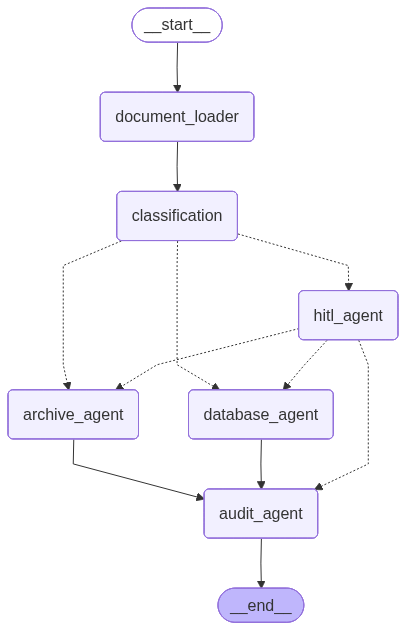

In [9]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

## 10. Process Document Helper

In [10]:
def process_document(file_path: str, thread_id: str = None) -> AgentState:
    file_name = Path(file_path).name
    config    = {"configurable": {"thread_id": thread_id or file_name}}

    initial_state: AgentState = {
        "file_path":      file_path,
        "file_name":      file_name,
        "date_received":  datetime.utcnow().strftime("%Y-%m-%d"),
        "raw_text":       "",
        "load_error":     None,
        "classification": None,
        "human_decision": None,
        "db_record":      None,
        "archive_record": None,
        "audit_entries":  [],
        "messages":       [],
    }

    print(f"\nProcessing: {file_name}")
    final_state = graph.invoke(initial_state, config=config)

    cls   = final_state.get("classification")
    label = cls.label if cls else "UNKNOWN"
    conf  = f"{cls.confidence:.0%}" if cls else "N/A"
    print(f"Result: {label}  (confidence: {conf})")

    return final_state


print("process_document() ready")

process_document() ready


## 11. Upload and Process Documents


In [11]:

results = {}
print("upload PDFs.")

upload PDFs.


In [12]:

LOCAL_PDF_FILES = [
]

newly_uploaded = []

IN_COLAB = False
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    pass

if IN_COLAB:
    from google.colab import files as colab_files
    print("Select one or more PDF files in the picker below.")
    print("Processing starts automatically once all files are uploaded.")
    print()

    uploaded_dict = colab_files.upload()

    if not uploaded_dict:
        print("No files selected.")
    else:
        for fname, fbytes in uploaded_dict.items():
            with open(fname, "wb") as fh:
                fh.write(fbytes)
            newly_uploaded.append(fname)

        print(f"\n{len(newly_uploaded)} file(s) uploaded:")
        for p in newly_uploaded:
            print(f"  {p}  ({Path(p).stat().st_size // 1024} KB)")
else:
    for p in LOCAL_PDF_FILES:
        if Path(p).exists():
            newly_uploaded.append(p)
        else:
            print(f"File not found, skipping: {p}")

    if newly_uploaded:
        print(f"Found {len(newly_uploaded)} local PDF file(s)")
    else:
        print("No files found. Add paths to LOCAL_PDF_FILES above and re-run.")

if newly_uploaded:
    print(f"\nStarting pipeline for {len(newly_uploaded)} document(s)...")
    print("-" * 60)

    for pdf_path in newly_uploaded:
        if pdf_path in results:
            print(f"Skipping (already processed): {pdf_path}")
            continue
        results[pdf_path] = process_document(pdf_path)

    print("-" * 60)
    print(f"Done. Total documents in session: {len(results)}")

Select one or more PDF files in the picker below.
Processing starts automatically once all files are uploaded.



Saving 01_copyright_infringement_photography.pdf to 01_copyright_infringement_photography.pdf
Saving 02_trademark_infringement_tech.pdf to 02_trademark_infringement_tech.pdf
Saving 03_trade_secret_misappropriation.pdf to 03_trade_secret_misappropriation.pdf
Saving 04_defamation_online_review.pdf to 04_defamation_online_review.pdf
Saving 05_patent_infringement_medical_device.pdf to 05_patent_infringement_medical_device.pdf
Saving 06_harassment_workplace.pdf to 06_harassment_workplace.pdf
Saving 07_software_license_violation.pdf to 07_software_license_violation.pdf
Saving 08_non_compete_violation.pdf to 08_non_compete_violation.pdf
Saving 09_copyright_infringement_music.pdf to 09_copyright_infringement_music.pdf
Saving 10_breach_of_contract_nda.pdf to 10_breach_of_contract_nda.pdf
Saving bw_doc_1.pdf to bw_doc_1.pdf
Saving bw_doc_2.pdf to bw_doc_2.pdf
Saving bw_doc_3.pdf to bw_doc_3.pdf
Saving bw_doc_4.pdf to bw_doc_4.pdf
Saving bw_doc_5.pdf to bw_doc_5.pdf
Saving LoA1.pdf to LoA1.pdf
Sa

/tmp/ipykernel_382/4269121173.py:8: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "date_received":  datetime.utcnow().strftime("%Y-%m-%d"),
/tmp/ipykernel_382/2150924860.py:15: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),
/tmp/ipykernel_382/2150924860.py:96: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp":  datetime.utcnow().isoformat(),
/tmp/ipykernel_382/2310231708.py:38: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a

Result: CEASE  (confidence: 100%)

Processing: 02_trademark_infringement_tech.pdf
Result: CEASE  (confidence: 100%)

Processing: 03_trade_secret_misappropriation.pdf
Result: CEASE  (confidence: 100%)

Processing: 04_defamation_online_review.pdf
Result: CEASE  (confidence: 100%)

Processing: 05_patent_infringement_medical_device.pdf
Result: CEASE  (confidence: 100%)

Processing: 06_harassment_workplace.pdf
Result: CEASE  (confidence: 99%)

Processing: 07_software_license_violation.pdf
Result: CEASE  (confidence: 100%)

Processing: 08_non_compete_violation.pdf
Result: CEASE  (confidence: 100%)

Processing: 09_copyright_infringement_music.pdf
Result: CEASE  (confidence: 100%)

Processing: 10_breach_of_contract_nda.pdf


/tmp/ipykernel_382/2150924860.py:25: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),
/tmp/ipykernel_382/2150924860.py:74: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),


Result: CEASE  (confidence: 100%)

Processing: bw_doc_1.pdf

----------------------------------------------------------------------
HUMAN REVIEW REQUIRED
----------------------------------------------------------------------
File       : bw_doc_1.pdf
Received   : 2026-03-24
AI Label   : UNCERTAIN  (confidence: 0%)
AI Reason  : Document could not be loaded: No extractable text -- may be a
scanned image PDF

Document preview (first 800 chars):
----------------------------------------------------------------------

----------------------------------------------------------------------

Options:
  1 - CEASE      : treat as valid C&D, store in database
  2 - IRRELEVANT : not a C&D request, archive
  3 - SKIP       : do nothing

Enter 1 / 2 / 3: 2


/tmp/ipykernel_382/2150924860.py:255: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),
/tmp/ipykernel_382/2150924860.py:191: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "archived_at":   datetime.utcnow().isoformat()
/tmp/ipykernel_382/2150924860.py:197: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),



Decision recorded: IRRELEVANT

Result: UNCERTAIN  (confidence: 0%)

Processing: bw_doc_2.pdf

----------------------------------------------------------------------
HUMAN REVIEW REQUIRED
----------------------------------------------------------------------
File       : bw_doc_2.pdf
Received   : 2026-03-24
AI Label   : UNCERTAIN  (confidence: 0%)
AI Reason  : Document could not be loaded: No extractable text -- may be a
scanned image PDF

Document preview (first 800 chars):
----------------------------------------------------------------------

----------------------------------------------------------------------

Options:
  1 - CEASE      : treat as valid C&D, store in database
  2 - IRRELEVANT : not a C&D request, archive
  3 - SKIP       : do nothing

Enter 1 / 2 / 3: 3

Decision recorded: SKIP

Result: UNCERTAIN  (confidence: 0%)

Processing: bw_doc_3.pdf

----------------------------------------------------------------------
HUMAN REVIEW REQUIRED
--------------------------------

## 12. Results Table

In [13]:
rows = []
for path, state in results.items():
    cls = state.get("classification")
    rows.append([
        Path(path).name,
        cls.label if cls else "UNKNOWN",
        f"{cls.confidence:.0%}" if cls else "N/A",
        cls.sender_name or "" if cls else "",
        cls.violation_type or "" if cls else "",
        cls.deadline or "" if cls else "",
        state.get("human_decision") or "",
    ])

headers = ["File", "Label", "Confidence", "Sender", "Violation Type", "Deadline", "Human Override"]
print(tabulate(rows, headers=headers, tablefmt="grid"))

+-------------------------------------------+------------+--------------+---------------------------------------------------------------+---------------------------------------------------------------------------------------------------+-------------------+------------------+
| File                                      | Label      | Confidence   | Sender                                                        | Violation Type                                                                                    | Deadline          | Human Override   |
+===========================================+============+==============+===============================================================+===================================================================================================+===================+==================+
| 01_copyright_infringement_photography.pdf | CEASE      | 100%         | Priya Nair Photography LLC                                    | Copyright Infringement         

## 13. Query the Database

In [14]:
conn = sqlite3.connect(DB_PATH)
conn.row_factory = sqlite3.Row
rows_db = conn.execute("SELECT * FROM cease_records ORDER BY inserted_at").fetchall()
conn.close()

if rows_db:
    print(f"CEASE RECORDS IN DATABASE ({len(rows_db)} records)\n")
    for i, row in enumerate(rows_db, 1):
        print(f"Record #{i}")
        print(f"  File            : {row['file_name']}")
        print(f"  Date Received   : {row['date_received']}")
        print(f"  Sender          : {row['sender_name']}")
        print(f"  Recipient       : {row['recipient_name']}")
        print(f"  Violation Type  : {row['violation_type']}")
        print(f"  Deadline        : {row['deadline']}")
        print(f"  Demands         : {row['demands_summary']}")
        print(f"  Confidence      : {row['confidence']:.0%}")
        print(f"  HITL Reviewed   : {'Yes' if row['hitl_reviewed'] else 'No'}")
        print(f"  Human Decision  : {row['human_decision'] or 'N/A'}")
        print()
else:
    print("No CEASE records in database.")

CEASE RECORDS IN DATABASE (18 records)

Record #1
  File            : 01_copyright_infringement_photography.pdf
  Date Received   : 2026-03-24
  Sender          : Priya Nair Photography LLC
  Recipient       : Mr. David Chen, Marketing Director, BrightLeaf Digital Agency
  Violation Type  : Copyright Infringement
  Deadline        : April 9, 2026
  Demands         : Remove photographs from website and social media, destroy printed materials, provide accounting of revenues, pay statutory damages, and provide written undertaking to cease unauthorized use
  Confidence      : 100%
  HITL Reviewed   : No
  Human Decision  : N/A

Record #2
  File            : 02_trademark_infringement_tech.pdf
  Date Received   : 2026-03-24
  Sender          : Jonathan Marks, Esq. of Marks & Sullivan LLP
  Recipient       : Ms. Rachel Torres, CEO of NovaSpark Technologies Inc.
  Violation Type  : Trademark Infringement and Unfair Competition
  Deadline        : March 30, 2026
  Demands         : Cease use of

## 14. View Archive

In [15]:
archive_file = Path(ARCHIVE_PATH)
if archive_file.exists():
    records = [json.loads(line) for line in archive_file.read_text().splitlines() if line.strip()]
    if records:
        print(f"ARCHIVED DOCUMENTS ({len(records)} records)\n")
        for r in records:
            print(f"  {r['file_name']}  |  received: {r['date_received']}  |  archived: {r['archived_at']}")
    else:
        print("Archive file is empty.")
else:
    print("No archive file found.")

ARCHIVED DOCUMENTS (7 records)

  bw_doc_1.pdf  |  received: 2026-03-24  |  archived: 2026-03-24T16:22:41.908390
  bw_doc_4.pdf  |  received: 2026-03-24  |  archived: 2026-03-24T16:22:47.587862
  LOA7.pdf  |  received: 2026-03-24  |  archived: 2026-03-24T16:23:05.266253
  LOA9.pdf  |  received: 2026-03-24  |  archived: 2026-03-24T16:23:20.970089
  notice_1.pdf  |  received: 2026-03-24  |  archived: 2026-03-24T16:23:23.449582
  notice_3.pdf  |  received: 2026-03-24  |  archived: 2026-03-24T16:23:26.568087
  notice_5.pdf  |  received: 2026-03-24  |  archived: 2026-03-24T16:23:30.475692


## 15. Audit Trail

In [16]:
audit_file = Path(AUDIT_PATH)
if audit_file.exists():
    entries = [json.loads(line) for line in audit_file.read_text().splitlines() if line.strip()]
    print(f"AUDIT LOG ({len(entries)} entries)\n")
    for entry in entries:
        override = f" | human override: {entry['human_override']}" if entry.get("human_override") else ""
        print(f"  [{entry['timestamp']}] {entry['file']} -> {entry['final_label']}{override}")
        for step in entry.get("pipeline_log", []):
            print(f"    [{step['agent']}] {step.get('status', '')} -- {step.get('detail', '')[:80]}")
        print()
else:
    print("Audit log not found.")

AUDIT LOG (29 entries)

  [2026-03-24T16:22:19.646560] 01_copyright_infringement_photography.pdf -> CEASE
    [DocumentLoaderAgent] success -- Extracted 3154 characters from 2 page(s)
    [ClassificationAgent] success -- The document is a clear, formal Cease and Desist letter with explicit legal dema
    [DatabaseAgent] success -- Inserted record 01_copyright_infringement_photography.pdf_2026-03-24

  [2026-03-24T16:22:20.293144] 02_trademark_infringement_tech.pdf -> CEASE
    [DocumentLoaderAgent] success -- Extracted 3247 characters from 2 page(s)
    [ClassificationAgent] success -- The document is a clear, formal Cease and Desist letter with explicit legal dema
    [DatabaseAgent] success -- Inserted record 02_trademark_infringement_tech.pdf_2026-03-24

  [2026-03-24T16:22:21.171078] 03_trade_secret_misappropriation.pdf -> CEASE
    [DocumentLoaderAgent] success -- Extracted 3528 characters from 2 page(s)
    [ClassificationAgent] success -- The document is a clear, formal Cease an

## 16. Process a Single File

In [17]:
# Change the filename below to process any individual document
single_file = "notice_1.pdf"

if Path(single_file).exists():
    state = process_document(single_file, thread_id=f"single_{single_file}")
    cls   = state.get("classification")
    if cls:
        print()
        print(f"Label          : {cls.label}")
        print(f"Confidence     : {cls.confidence:.0%}")
        print(f"Sender         : {cls.sender_name}")
        print(f"Recipient      : {cls.recipient_name}")
        print(f"Violation Type : {cls.violation_type}")
        print(f"Deadline       : {cls.deadline}")
        print(f"Demands        : {cls.demands_summary}")
        print(f"Reason         : {textwrap.fill(cls.reason, 65)}")
else:
    print(f"File not found: {single_file}")

/tmp/ipykernel_382/4269121173.py:8: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "date_received":  datetime.utcnow().strftime("%Y-%m-%d"),
/tmp/ipykernel_382/2150924860.py:25: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),
/tmp/ipykernel_382/2150924860.py:74: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),



Processing: notice_1.pdf

----------------------------------------------------------------------
HUMAN REVIEW REQUIRED
----------------------------------------------------------------------
File       : notice_1.pdf
Received   : 2026-03-24
AI Label   : UNCERTAIN  (confidence: 0%)
AI Reason  : Document could not be loaded: No extractable text -- may be a
scanned image PDF

Document preview (first 800 chars):
----------------------------------------------------------------------

----------------------------------------------------------------------

Options:
  1 - CEASE      : treat as valid C&D, store in database
  2 - IRRELEVANT : not a C&D request, archive
  3 - SKIP       : do nothing

Enter 1 / 2 / 3: 2

Decision recorded: IRRELEVANT

Result: UNCERTAIN  (confidence: 0%)

Label          : UNCERTAIN
Confidence     : 0%
Sender         : None
Recipient      : None
Violation Type : None
Deadline       : None
Demands        : None
Reason         : Document could not be loaded: No extrac

/tmp/ipykernel_382/2150924860.py:255: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),
/tmp/ipykernel_382/2150924860.py:191: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "archived_at":   datetime.utcnow().isoformat()
/tmp/ipykernel_382/2150924860.py:197: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),
/tmp/ipykernel_382/2150924860.py:283: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future

## 17. Summary

In [18]:
from collections import Counter

labels = [
    state["classification"].label
    for state in results.values()
    if state.get("classification")
]
counts = Counter(labels)
total  = len(labels)

print("PROCESSING SUMMARY")
print("-" * 40)
print(f"  Total documents : {total}")
print(f"  CEASE           : {counts.get('CEASE', 0):3d}  ({counts.get('CEASE', 0) / total * 100:.0f}%)")
print(f"  UNCERTAIN       : {counts.get('UNCERTAIN', 0):3d}  ({counts.get('UNCERTAIN', 0) / total * 100:.0f}%)")
print(f"  IRRELEVANT      : {counts.get('IRRELEVANT', 0):3d}  ({counts.get('IRRELEVANT', 0) / total * 100:.0f}%)")
print("-" * 40)

cease_confs = [
    state["classification"].confidence
    for state in results.values()
    if state.get("classification") and state["classification"].label == "CEASE"
]
if cease_confs:
    print(f"  Avg confidence (CEASE) : {sum(cease_confs) / len(cease_confs):.0%}")

PROCESSING SUMMARY
----------------------------------------
  Total documents : 29
  CEASE           :  16  (55%)
  UNCERTAIN       :  11  (38%)
  IRRELEVANT      :   2  (7%)
----------------------------------------
  Avg confidence (CEASE) : 96%


## 18. Verify Storage in Colab



In [19]:
# Check which storage files exist in the current Colab session
import os

files_to_check = {
    "cease_desist.db":          "SQLite database (CEASE records)",
    "irrelevant_archive.jsonl": "Archive flat file (IRRELEVANT records)",
    "audit_log.jsonl":          "Audit log (all documents)",
}

for fname, description in files_to_check.items():
    if os.path.exists(fname):
        size = os.path.getsize(fname)
        print(f"  EXISTS  {fname}  ({size} bytes) -- {description}")
    else:
        print(f"  MISSING {fname} -- {description}")

  EXISTS  cease_desist.db  (28672 bytes) -- SQLite database (CEASE records)
  EXISTS  irrelevant_archive.jsonl  (2385 bytes) -- Archive flat file (IRRELEVANT records)
  EXISTS  audit_log.jsonl  (26123 bytes) -- Audit log (all documents)


In [20]:
# Inspect the SQLite database directly
conn = sqlite3.connect("cease_desist.db")
conn.row_factory = sqlite3.Row

rows = conn.execute("SELECT * FROM cease_records ORDER BY inserted_at").fetchall()
conn.close()

if rows:
    table = [
        [r["file_name"], r["date_received"], r["sender_name"],
         r["violation_type"], r["deadline"], f"{r['confidence']:.0%}",
         "Yes" if r["hitl_reviewed"] else "No", r["human_decision"] or "N/A", r["inserted_at"]]
        for r in rows
    ]
    headers = ["File", "Date Received", "Sender", "Violation Type", "Deadline", "Confidence", "HITL Reviewed", "Human Decision", "Inserted At"]
    print(f"cease_records -- {len(rows)} row(s)\n")
    print(tabulate(table, headers=headers, tablefmt="grid"))
else:
    print("No rows in cease_records yet.")

cease_records -- 18 row(s)

+-------------------------------------------+-----------------+---------------------------------------------------------------+---------------------------------------------------------------------------------------------------+-------------------+--------------+-----------------+------------------+----------------------------+
| File                                      | Date Received   | Sender                                                        | Violation Type                                                                                    | Deadline          | Confidence   | HITL Reviewed   | Human Decision   | Inserted At                |
+===========================================+=================+===============================================================+===================================================================================================+===================+==============+=================+==================+===============

In [21]:
# Run a custom SQL query against the database
conn = sqlite3.connect("cease_desist.db")

# Change the query below to explore the data
query = "SELECT file_name, violation_type, confidence FROM cease_records ORDER BY confidence DESC"

rows = conn.execute(query).fetchall()
conn.close()

for row in rows:
    print(row)

('01_copyright_infringement_photography.pdf', 'Copyright Infringement', 1.0)
('02_trademark_infringement_tech.pdf', 'Trademark Infringement and Unfair Competition', 1.0)
('03_trade_secret_misappropriation.pdf', 'Misappropriation of Trade Secrets', 1.0)
('04_defamation_online_review.pdf', 'Defamation', 1.0)
('05_patent_infringement_medical_device.pdf', 'Patent Infringement — U.S. Patent Nos. 11,234,567 and 11,345,678', 1.0)
('07_software_license_violation.pdf', 'Copyright Infringement, Computer Fraud and Abuse Act, and breach of contract', 1.0)
('08_non_compete_violation.pdf', 'Breach of Non-Compete and Non-Solicitation Agreement', 1.0)
('09_copyright_infringement_music.pdf', 'Copyright Infringement', 1.0)
('10_breach_of_contract_nda.pdf', 'Breach of Non-Disclosure Agreement — Unauthorized Disclosure of Confidential Business Information', 1.0)
('06_harassment_workplace.pdf', 'Workplace Harassment, Discrimination, and Retaliation', 0.99)
('LoA1.pdf', None, 0.9)
('LOA2.pdf', None, 0.9)
('